In [1]:
from arcgis.gis import GIS
from arcgis.raster import ImageryLayer
import pandas as pd
from arcgis.raster.functions import apply
from IPython.display import HTML
from ipywidgets import HBox, Layout
from arcgis.geometry import Geometry

C:\Users\odin0\AppData\Local\ESRI\conda\envs\arcgispro-py3-clone\Lib\site-packages\dask\dataframe\__init__.py:49: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
gis = GIS("pro")
print("Logged in as:", gis.properties.user.username)

Logged in as: 1015152_HR_IGO


<Item title:"Landsat 8-9 Normalized Difference Vegetation Index (NDVI) Colorized" type:Imagery Layer owner:esri>
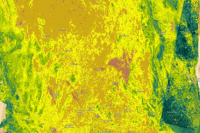

In [3]:
landsat_item = gis.content.get("f6bb66f1c11e467f9a9a859343e27cf8")
landsat_item

In [4]:
m1 = gis.map()

m1.content.add(landsat_item)

# Set Rotterdam view safely
m1.center = [51.92, 4.48]   # Rotterdam approx center
m1.zoom = 11                # Good zoom level

m1


Map(center=[51.92, 4.48], extent={'xmin': 476032.1762551673, 'ymin': 6747911.175313494, 'xmax': 522576.3602295…

<Item title:"knmi_grondwater" type:Feature Layer Collection owner:1015152_HR_IGO>
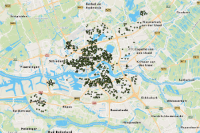

In [5]:
gw = gis.content.get("c0be87e3044348eebb5a83e65cfb9016")
gw

In [6]:
m2 = gis.map()

m2.content.add(gw)

m2.center = [51.92, 4.48]   # Rotterdam
m2.zoom = 11

m2


Map(center=[51.92, 4.48], extent={'xmin': 476032.1762551673, 'ymin': 6747911.175313494, 'xmax': 522576.3602295…

In [7]:
def side_by_side(m1, m2):
    m1.sync_navigation(m2)

    m1.layout = Layout(width="50%", height="500px")
    m2.layout = Layout(width="50%", height="500px")

    return HBox([m1, m2])


In [9]:
#side_by_side(m1, m2)